# A small MMD particle flow

Compare three geometries for the same smoothed energy-distance
objective. `mmd_force` returns the mean-field force, already scaled
for use with `particle_lmo`. These are small explicit Euler examples,
not calibrated speed comparisons or the paper's full experiments.
Blue points are the target, red points the final particles, and gray
lines their trajectories. The three spatial panels share axis limits.

Run from an environment with `pip install -e '.[notebooks,transport]'` from
the repository root. In Colab, first run
`%pip install 'muon-dynamics[notebooks,transport] @ git+https://github.com/gpeyre/muon-dynamics.git'`.
All particle arrays have particles in rows. No training data are downloaded.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import muon_dynamics as md

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})


Matplotlib is building the font cache; this may take a moment.


In [2]:
rng = np.random.default_rng(7)
source = rng.normal(size=(32, 2)) * [.7, .3] + [1.8, 1.]
target = np.r_[rng.normal(size=(24, 2))*.25 + [-1, .7],
               rng.normal(size=(24, 2))*.3 + [1, -.7]]
dt, steps = .025, 160
histories, energies = {}, {}
for p in [1, 2, np.inf]:
    x = source.copy()
    history, energy = [x.copy()], [md.mmd_energy(x, target)]
    for _ in range(steps):
        velocity = md.particle_lmo(md.mmd_force(x, target), p)
        x = x + dt*velocity
        history.append(x.copy())
        energy.append(md.mmd_energy(x, target))
    histories[p], energies[p] = np.array(history), np.array(energy)
    assert energy[-1] < energy[0]


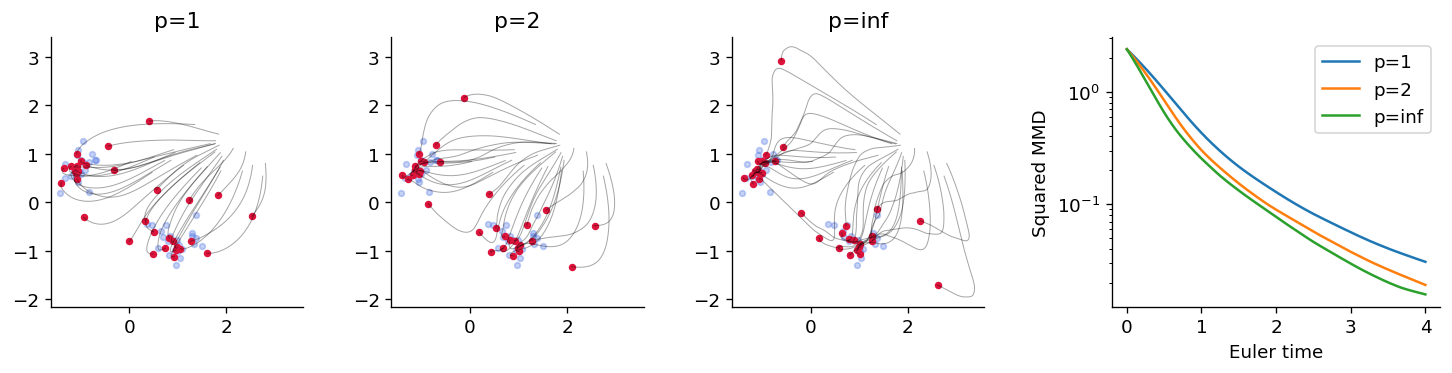

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True)
all_points = np.concatenate([target] + [h.reshape(-1, 2) for h in histories.values()])
lower, upper = all_points.min(axis=0)-.2, all_points.max(axis=0)+.2
for ax, p in zip(axes, histories):
    h = histories[p]
    ax.scatter(*target.T, s=12, color="royalblue", alpha=.3)
    ax.plot(h[:, :, 0], h[:, :, 1], color="black", lw=.6, alpha=.35)
    ax.scatter(*h[-1].T, s=12, color="crimson")
    ax.set(title=f"p={p:g}", aspect="equal",
           xlim=(lower[0], upper[0]), ylim=(lower[1], upper[1]))
    axes[-1].semilogy(np.arange(steps+1)*dt, energies[p], label=f"p={p:g}")
axes[-1].set(xlabel="Euler time", ylabel="Squared MMD")
axes[-1].legend()
fig.savefig("02_particle_mmd.png", dpi=130)
plt.show()
